In [1]:
from tabnanny import verbose

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
df = pd.read_csv ("galton.csv")
#tinha uma coluna a mais vazia...
#df = df.drop("Unnamed: 9", axis=1)
#df.dropna(axis=1, how='all', inplace=True)
df.head(10)

,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,78.5,67.0,75.43,4,1,male,73.2
1,1,78.5,67.0,75.43,4,2,female,69.2
2,1,78.5,67.0,75.43,4,3,female,69.0
3,1,78.5,67.0,75.43,4,4,female,69.0
4,2,75.5,66.5,73.66,4,1,male,73.5
5,2,75.5,66.5,73.66,4,2,male,72.5
6,2,75.5,66.5,73.66,4,3,female,65.5
7,2,75.5,66.5,73.66,4,4,female,65.5
8,3,75.0,64.0,72.06,2,1,male,71.0
9,3,75.0,64.0,72.06,2,2,female,68.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   family           934 non-null    str    
 1   father           934 non-null    float64
 2   mother           934 non-null    float64
 3   midparentHeight  934 non-null    float64
 4   children         934 non-null    int64  
 5   childNum         934 non-null    int64  
 6   gender           934 non-null    str    
 7   childHeight      934 non-null    float64
dtypes: float64(4), int64(2), str(2)
memory usage: 58.5 KB


Existem 0 duplicados


C:\Users\jotav\AppData\Local\Temp\ipykernel_6640\1774825619.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


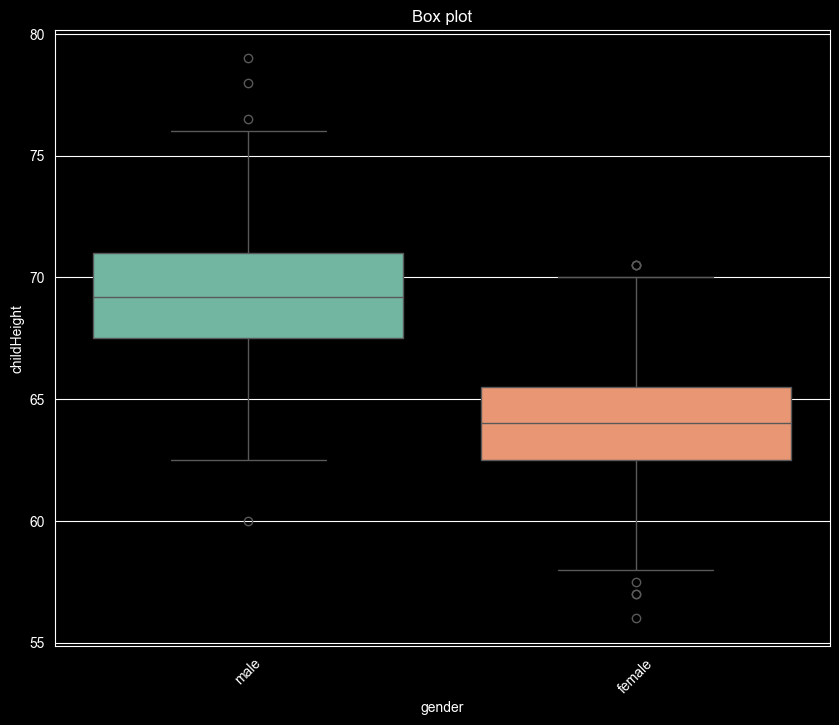

In [4]:
#verificar se há duplicados
duplicado = df.duplicated().sum()
print(f"Existem {duplicado} duplicados")

#verificar se há outliers )
plt.figure(figsize=(10, 8))
sns.boxplot(
    x='gender',
    y='childHeight',
    data=df,
    palette="Set2",
    #fliersize=5 # muda o tamanho do outlier
)
plt.title("Box plot")
plt.xticks(rotation=45)
plt.show()

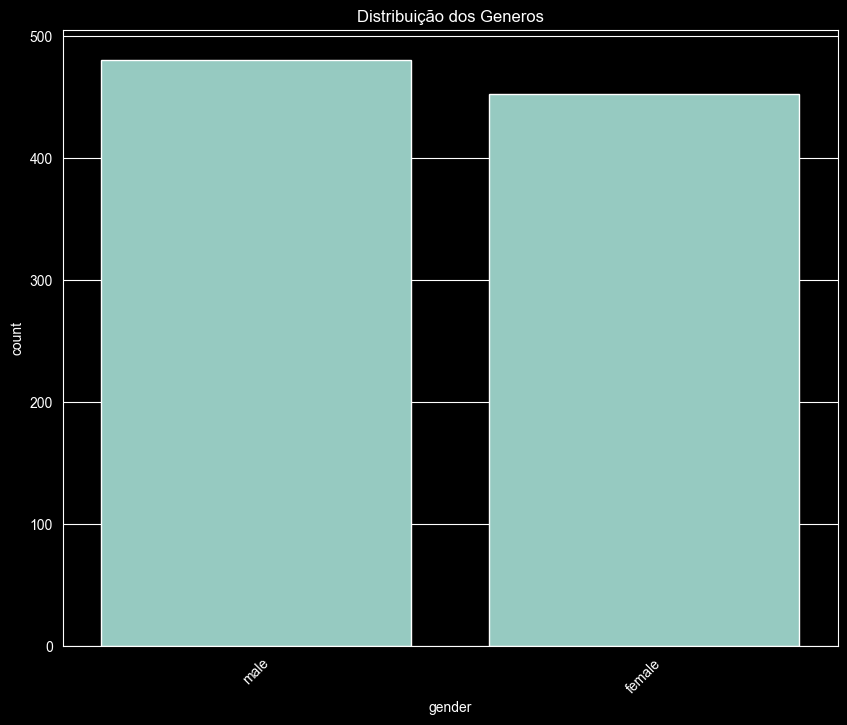

In [5]:
#distribuicao dos labels (para ver se existem amostras o suficiente de cada, )
plt.figure(figsize=(10, 8) )
sns.countplot(x='gender', data=df)
plt.title("Distribuição dos Generos")
plt.xticks(rotation=45)
plt.show()

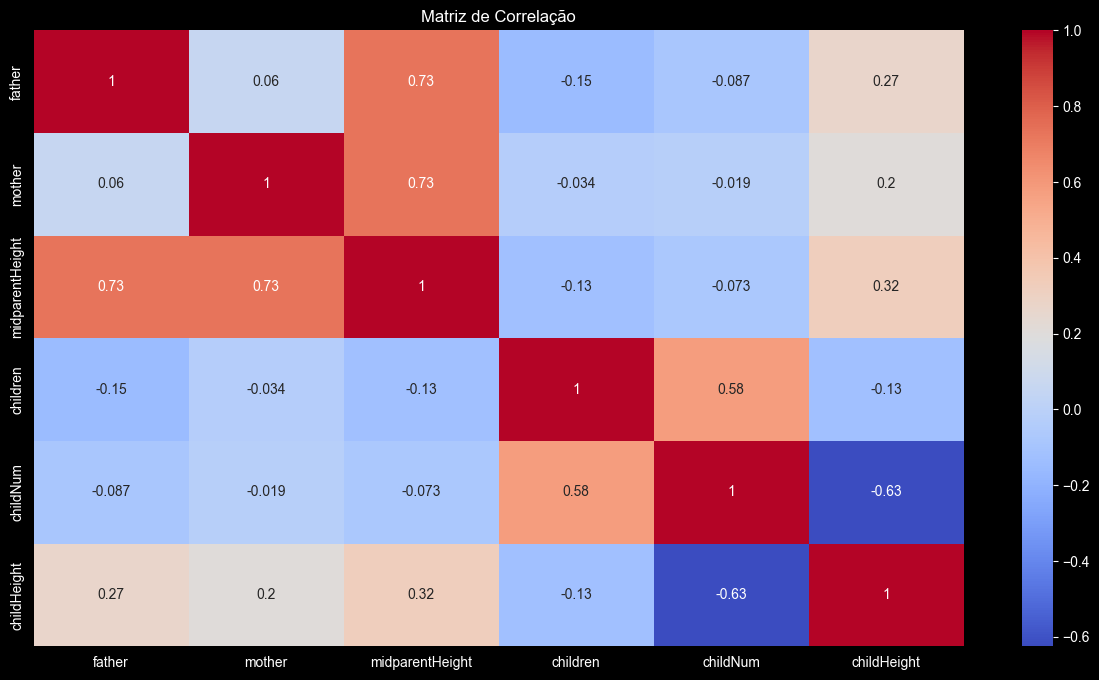

In [6]:
# Correlação entre as features numéricas,( nao daria pra excluir uma variavel no treino ? para esse pensamento serve o esse grafico // multicolinearidade, especialmente para modelos de regressao multipla)

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
plt.figure(figsize=(15,8))
sns.heatmap(df.select_dtypes(include=numerics).corr(), annot=True,cmap='coolwarm' )
plt.title("Matriz de Correlação")
plt.show()

In [7]:
#LIMPEZA DO DADOS ########################################################################

In [8]:

#tratar outliers, (substituir por media, mediana e etc..)

# 1. Calcula a matemática exata do Boxplot (Regra do IQR)
# q1 = df['Potassium'].quantile(0.25)
# q3 = df['Potassium'].quantile(0.75)
# iqr = q3 - q1
#
# limite_superior = q3 + 1.5 * iqr  # Esse é o limite do "bigode" de cima (aprox 18)
# limite_inferior = q1 - 1.5 * iqr  # Esse é o limite do "bigode" de baixo
#
#
#
# # 2. Descobre a mediana
# median_potassium = df['Potassium'].median()
# df['Potassium'] = df['Potassium'].apply(lambda x: median_potassium if x > limite_superior or x < limite_inferior else x)
#
# plt.figure(figsize=(10, 8), facecolor='white')
# sns.boxplot(
#     data=df,
#     palette="Set2",
#     fliersize=5 )# muda o tamanho do outlier)



# NESSE CASO O OUTLINER VIROU O 18, PQ AO TRAZER O 19 PARA A MEDIANA (0) O SISTEMA FICOU MAIS RIGOROSO E O 18 FOI CORTADO.




In [9]:

#tratar com %, como mostrado no video
# median_potassium = df['Potassium'].median()
# df['Potassium'] = df['Potassium'].apply(lambda x: median_potassium if x > df['Potassium'].quantile(0.975) or x < df['Potassium'].quantile(0.025) else x)
#
# plt.figure(figsize=(10, 8), facecolor='white')
# sns.boxplot(
#     data=df,
#     palette="Set2",
#     fliersize=5) # muda o tamanho do outlier

# excluir os 2.5% mais altos .



In [10]:
# Alterar o resultado outliner manualmente

# # 1. Calcula os limites matemáticos do Boxplot (Regra do IQR)
# q1 = df['Potassium'].quantile(0.25)
# q3 = df['Potassium'].quantile(0.75)
# iqr = q3 - q1
#
# # Esse é o limite do "bigode" de cima (a fronteira do aceitável)
# limite_superior = q3 + 1.5 * iqr
#
# # 2. Aplica o Capping (Teto)
# # Tradução: Onde o Potássio for maior que o limite, ele vira o próprio limite.
# # 2. Aplica o Capping (Teto) garantindo que é um número inteiro
# limite_inteiro = int(limite_superior)
# df.loc[df['Potassium'] > limite_superior, 'Potassium'] = limite_inteiro
#
# plt.figure(figsize=(10, 8), facecolor='white')
# sns.boxplot(
#     data=df,
#     palette="Set2",
#     fliersize=5) # muda o tamanho do outlier



# forcei o 19 virar 18 para nao ser um outlier. (existem 2x o 19, baixa chance de ser erro no sensor)


In [49]:
# 1. Limpeza
df.drop(columns=['children', 'childNum', 'family'], inplace=True, errors='ignore')
df = df.drop_duplicates()

# x = remove a coluna(axis1) do fertilizer..
X = df.drop("childHeight", axis=1)
y = df["childHeight"]

# remove os nomes e transforma a tabela em números 1,2,3
##le = LabelEncoder()
#y = le.fit_transform(y)

# Converte altura contínua em 3 classes para classificação NAO PRECISA DESSA PARTE SE FOR REGRESSAO
y = pd.qcut(
    df["childHeight"],
    q=3,
    labels=["baixo", "medio", "alto"]
)

#oneHotEncoder cria multiplas colunas de 0 e 1 para tirar o nome, se usar o laberEncoder os numeros diferente fariam o codigo achar que os solos tem importancias diferentes, se quiser colocar importancias diferentes : ordinalencoder
categorical_cols = ["gender"]
ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
X_encoded = pd.DataFrame(
    ohe.fit_transform(X[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X.index
)

# remove colunas com nomes (mudamos para numero)

X = X.drop(columns=categorical_cols)
X = pd.concat([X, X_encoded], axis=1)


print(X.shape)
print(y.shape)




(752, 5)
(752,)


In [55]:

###############################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################

#----------------------------------------TREINAMENTO DOS DADOS ---------------------------------------------------

#nao APLICADO AQUI o DBSCAN / K-MEANS / Agglomerative Clustering
#treinamento do modelo. 20% teste



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # <- garante proporção igual em treino e teste
)
#scaler = StandardScaler()    >>>  pega a media da coluna e transforma em 0. o resto é prop de -3 a =3
#scaler = RobustScaler()     >>>> nao usa a media e sim a mediana, bom com outliers que nao posso tirar
#scaler = MaxAbsScaler()     >>>> amigo dos zeros, divide tudo pelo maior valor.
#scaler = MinMaxScaler()  # >>>transf o< de tds em 0, o > de tds em 1, e tudo dentro do intervalo

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
#REGRESSAO LOGISTICA ###########################################################

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
print("precisao da Regressão Logística:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg, zero_division=0))



precisao da Regressão Logística: 0.7748344370860927
              precision    recall  f1-score   support

        alto       0.33      0.10      0.15        10
       baixo       0.67      0.52      0.58        31
       medio       0.81      0.91      0.85       110

    accuracy                           0.77       151
   macro avg       0.60      0.51      0.53       151
weighted avg       0.75      0.77      0.75       151



In [32]:
# KNN #########################################################
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("Precisao do KNN:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Precisao do KNN: 0.7682119205298014
              precision    recall  f1-score   support

        alto       0.33      0.10      0.15        10
       baixo       0.63      0.55      0.59        31
       medio       0.81      0.89      0.85       110

    accuracy                           0.77       151
   macro avg       0.59      0.51      0.53       151
weighted avg       0.74      0.77      0.75       151



In [33]:
# SVM com kernel RBF -> mais complexo
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (RBF):", accuracy_score(y_test, y_pred_svm_rbf))
print(classification_report(y_test, y_pred_svm_rbf, zero_division=0))

# SVM com kernel polinomial -> intermediário
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train_scaled, y_train)
y_pred_svm_poly = svm_poly.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (Polinomial):", accuracy_score(y_test, y_pred_svm_poly))
print(classification_report(y_test, y_pred_svm_poly, zero_division=0))

# SVM com kernel linear -> o mais simples
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (Linear):", accuracy_score(y_test, y_pred_svm_linear))
print(classification_report(y_test, y_pred_svm_linear, zero_division=0))



Acurácia SVM (RBF): 0.7880794701986755
              precision    recall  f1-score   support

        alto       1.00      0.10      0.18        10
       baixo       0.67      0.52      0.58        31
       medio       0.81      0.93      0.86       110

    accuracy                           0.79       151
   macro avg       0.83      0.51      0.54       151
weighted avg       0.79      0.79      0.76       151

Acurácia SVM (Polinomial): 0.7549668874172185
              precision    recall  f1-score   support

        alto       1.00      0.10      0.18        10
       baixo       0.62      0.26      0.36        31
       medio       0.77      0.95      0.85       110

    accuracy                           0.75       151
   macro avg       0.79      0.44      0.47       151
weighted avg       0.75      0.75      0.71       151

Acurácia SVM (Linear): 0.7748344370860927
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00        10
  

In [34]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("Acurácia Decision Tree:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0)) # <-- Silencia o aviso

# Random Forest
rf = RandomForestClassifier(n_estimators=5)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0)) # <-- Silencia o aviso

Acurácia Decision Tree: 0.6158940397350994
              precision    recall  f1-score   support

        alto       0.16      0.40      0.23        10
       baixo       0.49      0.58      0.53        31
       medio       0.80      0.65      0.71       110

    accuracy                           0.62       151
   macro avg       0.48      0.54      0.49       151
weighted avg       0.69      0.62      0.64       151

Acurácia Random Forest: 0.6622516556291391
              precision    recall  f1-score   support

        alto       0.19      0.30      0.23        10
       baixo       0.49      0.55      0.52        31
       medio       0.80      0.73      0.76       110

    accuracy                           0.66       151
   macro avg       0.49      0.53      0.50       151
weighted avg       0.69      0.66      0.68       151



In [39]:

# Espiando a distribuição dos dados no teste
pd.DataFrame(y_test) \
    .value_counts() \
    .reset_index() \
    .rename(columns={"childHeight": "Classe", "count": "Quantidade"}) \
    .sort_values(by="Quantidade", ascending=False)

,Classe,Quantidade
0,medio,110
1,baixo,31
2,alto,10


In [40]:
#####################################   O MELHOR DOS HIPERPARAMETROS ###########

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


#tamanho da floresta
n_estimators = [int(x) for x in np.linspace(100,200, num=200)]
print(n_estimators)

[100, 100, 101, 101, 102, 102, 103, 103, 104, 104, 105, 105, 106, 106, 107, 107, 108, 108, 109, 109, 110, 110, 111, 111, 112, 112, 113, 113, 114, 114, 115, 115, 116, 116, 117, 117, 118, 118, 119, 119, 120, 120, 121, 121, 122, 122, 123, 123, 124, 124, 125, 125, 126, 126, 127, 127, 128, 128, 129, 129, 130, 130, 131, 131, 132, 132, 133, 133, 134, 134, 135, 135, 136, 136, 137, 137, 138, 138, 139, 139, 140, 140, 141, 141, 142, 142, 143, 143, 144, 144, 145, 145, 146, 146, 147, 147, 148, 148, 149, 149, 150, 150, 151, 151, 152, 152, 153, 153, 154, 154, 155, 155, 156, 156, 157, 157, 158, 158, 159, 159, 160, 160, 161, 161, 162, 162, 163, 163, 164, 164, 165, 165, 166, 166, 167, 167, 168, 168, 169, 169, 170, 170, 171, 171, 172, 172, 173, 173, 174, 174, 175, 175, 176, 176, 177, 177, 178, 178, 179, 179, 180, 180, 181, 181, 182, 182, 183, 183, 184, 184, 185, 185, 186, 186, 187, 187, 188, 188, 189, 189, 190, 190, 191, 191, 192, 192, 193, 193, 194, 194, 195, 195, 196, 196, 197, 197, 198, 198, 199, 200]

In [41]:

#valores a serem investigados para outros hiperparametros
max_features = [None, "sqrt"]
max_depth = [int(x) for x in np.linspace(5,30, num=15)]
min_samples_split = [2,5,10,20]
min_samples_leaf = [1,2,4,5,10]

In [42]:
#cria o grid de parametros
params = {
    "n_estimators": n_estimators,
    "max_features": max_features,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
}

In [ ]:
rfr = RandomForestRegressor(random_state=42)

In [ ]:
# GRID SEARCH, PESQUISA ENTRE TODAS AS COMBINACOES POSSIVEIS
grid_rfr = GridSearchCV(
    estimator=rfr,   #modelo que quero otimizar
    param_grid=params,  #quais os parametros ?
    cv=3,   # dividir em 3 folds para cross validations
    verbose=2,
    n_jobs=-1, #paralelizacao, quantos nucleos do meu pc quero usar ? -1 = todos

                        )

In [ ]:
#grid_rfr.fit(X_train, y_train) # parei com 40 min

In [ ]:
#RANDOM SEARCH,       PEGA X ALEATORIO DE TODAS AS POSSIBILIDADE E TRAZ A MELHOR (MUITO MAIS RAPIDO)

random_rfr = RandomizedSearchCV(
    estimator=rfr,   #modelo que quero otimizar
    param_distributions=params,  #quais os parametros ?
    cv=3,   # dividir em 3 folds para cross validations
    verbose=2,
    n_jobs=-1, #paralelizacao, quantos nucleos do meu pc quero usar ? -1 = todos
    random_state=42,
    n_iter=500
)


In [ ]:
random_rfr.fit(X_train, y_train)

In [ ]:
# mostra o melhor dos hiperparametros
random_rfr.best_params_

In [ ]:
# guarda o melhor modelo
random_rfr.best_estimator_

In [ ]:
best = random_rfr.best_estimator_
best.fit(X_train,y_train)
y_pred = best.predict(X_test)
y_pred


In [ ]:

rf = RandomForestClassifier(n_estimators=5)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))


In [56]:
###################### meu teste comparando o classifier antigo com o otimizador
rfc= RandomForestClassifier()
n_estimators_c = [int(x) for x in np.linspace(100,200, num=200)]
#print(n_estimators)

#valores a serem investigados para outros hiperparametros
max_features_c = [None, "sqrt"]
max_depth_c = [int(x) for x in np.linspace(5,30, num=15)]
min_samples_split_c = [2,5,10,20]
min_samples_leaf_c = [1,2,4,5,10]


params_class = {
    "n_estimators": n_estimators_c,
    "max_features": max_features_c,
    "max_depth": max_depth_c,
    "min_samples_split": min_samples_split_c,
    "min_samples_leaf": min_samples_leaf_c,
}

random_rfc = RandomizedSearchCV(
    estimator=rfc,   #modelo que quero otimizar
    param_distributions=params_class,  #quais os parametros ?
    cv=3,   # dividir em 3 folds para cross validations
    verbose=2,
    n_jobs=-1, #paralelizacao, quantos nucleos do meu pc quero usar ? -1 = todos
    random_state=42,
    n_iter=500
)

random_rfc.fit(X_train_scaled, y_train)








Fitting 3 folds for each of 500 candidates, totalling 1500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 6, ...], 'max_features': [None, 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",500
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionc

In [57]:
print("Melhores parâmetros:", random_rfc.best_params_)



Melhores parâmetros: {'n_estimators': 148, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 8}


In [58]:
y_pred_otimizado = random_rfc.predict(X_test_scaled)

In [59]:
print("Acurácia Random Forest Otimizado:", accuracy_score(y_test, y_pred_otimizado))
print("Relatório de Classificação Otimizado:\n")
print(classification_report(y_test, y_pred_otimizado, zero_division=0))

# Random Forest
rf = RandomForestClassifier(n_estimators=5)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0)) # <-- Silencia o aviso

print(y.value_counts())

Acurácia Random Forest Otimizado: 0.6158940397350994
Relatório de Classificação Otimizado:

              precision    recall  f1-score   support

        alto       0.64      0.78      0.70        50
       baixo       0.68      0.80      0.74        54
       medio       0.41      0.23      0.30        47

    accuracy                           0.62       151
   macro avg       0.58      0.60      0.58       151
weighted avg       0.58      0.62      0.59       151

Acurácia Random Forest: 0.5827814569536424
              precision    recall  f1-score   support

        alto       0.67      0.68      0.67        50
       baixo       0.66      0.72      0.69        54
       medio       0.37      0.32      0.34        47

    accuracy                           0.58       151
   macro avg       0.56      0.57      0.57       151
weighted avg       0.57      0.58      0.58       151

childHeight
baixo    271
alto     248
medio    233
Name: count, dtype: int64
